# Шаг 2. Углублённый EDA, поиск аномалий и обогащение данных

## Цель ноутбука
Углублённо исследовать датасет MovieLens, обнаружить аномалии тремя методами, обогатить фильмовые данные новыми признаками и сохранить итоговый датасет для следующего шага.

**Что делаем:**
- Анализ пропусков (с демонстрацией KNNImputer)
- Извлечение года выпуска из названия
- Анализ жанров и тегов
- Корреляционный анализ активности
- Поиск аномалий: Isolation Forest, One-Class SVM, DBSCAN
- Обогащение `movies_enriched.parquet`

**Что НЕ делаем:** сплит train/val/test, обучение моделей, data leakage (агрегаты из ratings в итоговый артефакт).

## 0. Импорты и настройки

In [1]:
import sys
import re
import warnings
warnings.filterwarnings('ignore')

sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

from src.utils import SEED, set_seeds
from src.preprocessing import extract_year_from_title

set_seeds()
sns.set_theme(style='whitegrid')

RAW_DIR  = Path('../data/raw')
PROC_DIR = Path('../data/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

print(f"SEED = {SEED}")
print(f"Данные: {RAW_DIR.resolve()}")
print(f"Результаты: {PROC_DIR.resolve()}")

SEED = 29042005
Данные: D:\Git-Project\project\data\raw
Результаты: D:\Git-Project\project\data\processed


## 1. Загрузка и быстрая сверка

In [2]:
ratings = pd.read_csv(RAW_DIR / 'ratings.csv')
movies  = pd.read_csv(RAW_DIR / 'movies.csv')
tags    = pd.read_csv(RAW_DIR / 'tags.csv')
links   = pd.read_csv(RAW_DIR / 'links.csv')

print(f"{'Файл':<12} {'Строки':>10} {'Колонки':>8}")
print("-" * 32)
for name, df in [('ratings', ratings), ('movies', movies), ('tags', tags), ('links', links)]:
    print(f"{name:<12} {df.shape[0]:>10,} {df.shape[1]:>8}")

Файл             Строки  Колонки
--------------------------------
ratings         100,836        4
movies            9,742        3
tags              3,683        4
links             9,742        3


## 2. Анализ пропусков

In [3]:
# Сводная таблица пропусков
frames = {'ratings': ratings, 'movies': movies, 'tags': tags, 'links': links}
missing_rows = []
for name, df in frames.items():
    for col in df.columns:
        n = df[col].isnull().sum()
        if n > 0:
            missing_rows.append({'датафрейм': name, 'колонка': col,
                                 'пропусков': n, '% строк': round(n/len(df)*100, 2)})

if missing_rows:
    display(pd.DataFrame(missing_rows))
else:
    print("Явных пропусков (NaN) не обнаружено ни в одном файле (кроме links.tmdbId)")

# Детальный анализ links.tmdbId
tmdb_null = links['tmdbId'].isnull().sum()
print(f"\nlinks['tmdbId']: {tmdb_null} NaN ({tmdb_null/len(links)*100:.1f}%)")

# Есть ли паттерн: старые фильмы без tmdbId?
links_with_year = links.merge(
    movies[['movieId', 'title']].assign(year=movies['title'].apply(extract_year_from_title)),
    on='movieId', how='left'
)
tmdb_by_null = links_with_year.groupby(links_with_year['tmdbId'].isnull())['year'].describe()
print("\nСтатистика года для фильмов с/без tmdbId:")
display(tmdb_by_null)

,датафрейм,колонка,пропусков,% строк
0,links,tmdbId,8,0.08



links['tmdbId']: 8 NaN (0.1%)

Статистика года для фильмов с/без tmdbId:


,count,mean,std,min,25%,50%,75%,max
tmdbId,,,,,,,,
False,9722.0,1994.617363,18.537108,1902.0,1988.0,1999.0,2008.0,2018.0
True,7.0,1989.428571,15.998512,1960.0,1984.5,1991.0,1999.0,2008.0


**Вывод по пропускам:**
- `links.tmdbId` — единственный столбец с NaN (~0.7%). Это структурный пропуск: некоторые фильмы из MovieLens не имеют связки с TMDb. Импутировать бессмысленно — это категориальный ID. В Streamlit такие фильмы будут показываться без постера.
- `tags.tag` — пропусков нет, но заполним пустой строкой на случай будущих данных.
- **Машинное заполнение (KNNImputer/IterativeImputer) применим в шаге 3** при формировании числовых признаков пользователя/фильма, если там обнаружатся пропуски, по принципу `fit на train → transform на val/test`.

## 3. Извлечение года выпуска

In [5]:
movies['year'] = movies['title'].apply(extract_year_from_title)

no_year = movies['year'].isnull().sum()
print(f"Фильмов без года: {no_year} ({no_year/len(movies)*100:.1f}%)")
print(f"Диапазон лет: {movies['year'].min():.0f} – {movies['year'].max():.0f}")
print()
print(movies['year'].describe())

Фильмов без года: 13 (0.1%)
Диапазон лет: 1902 – 2018

count    9729.000000
mean     1994.613629
std        18.535219
min      1902.000000
25%      1988.000000
50%      1999.000000
75%      2008.000000
max      2018.000000
Name: year, dtype: float64


In [6]:
# Гистограмма года (plotly)
year_data = movies['year'].dropna().astype(int)

fig = px.histogram(
    year_data, x=year_data, nbins=60,
    title='Распределение года выпуска фильмов',
    labels={'x': 'Год выпуска', 'y': 'Количество фильмов'},
    color_discrete_sequence=['steelblue']
)
fig.update_layout(bargap=0.05, height=400)
fig.show()

**Наблюдения по году выпуска:**
- Большинство фильмов в датасете вышли после 1990 года — наблюдается сильный скос к современным фильмам.
- Это ожидаемо: пользователи MovieLens преимущественно оценивают современное кино.
- Несколько фильмов без года — оставляем NaN, учтём при моделировании.

## 4. Анализ жанров

In [7]:
# Распарсить жанры
movies['genres_list'] = movies['genres'].apply(
    lambda g: [] if g == '(no genres listed)' else g.split('|')
)
movies['n_genres'] = movies['genres_list'].apply(len)
movies['no_genres_flag'] = movies['genres'] == '(no genres listed)'

print(f"Фильмов без жанра: {movies['no_genres_flag'].sum()}")
print(f"Среднее число жанров: {movies['n_genres'].mean():.2f}")
print(f"Распределение числа жанров:")
display(movies['n_genres'].value_counts().sort_index().to_frame('фильмов'))

Фильмов без жанра: 34
Среднее число жанров: 2.26
Распределение числа жанров:


,фильмов
n_genres,
0,34
1,2817
2,3218
3,2338
4,987
5,271
6,63
7,12
8,1


In [8]:
# Топ-15 жанров (plotly bar)
all_genres = movies['genres_list'].explode()
genre_counts = all_genres.value_counts().head(15).reset_index()
genre_counts.columns = ['genre', 'count']

fig = px.bar(
    genre_counts.sort_values('count'),
    x='count', y='genre', orientation='h',
    title='Топ-15 жанров по числу фильмов',
    labels={'count': 'Количество фильмов', 'genre': 'Жанр'},
    color='count', color_continuous_scale='Blues'
)
fig.update_layout(height=500, showlegend=False)
fig.show()

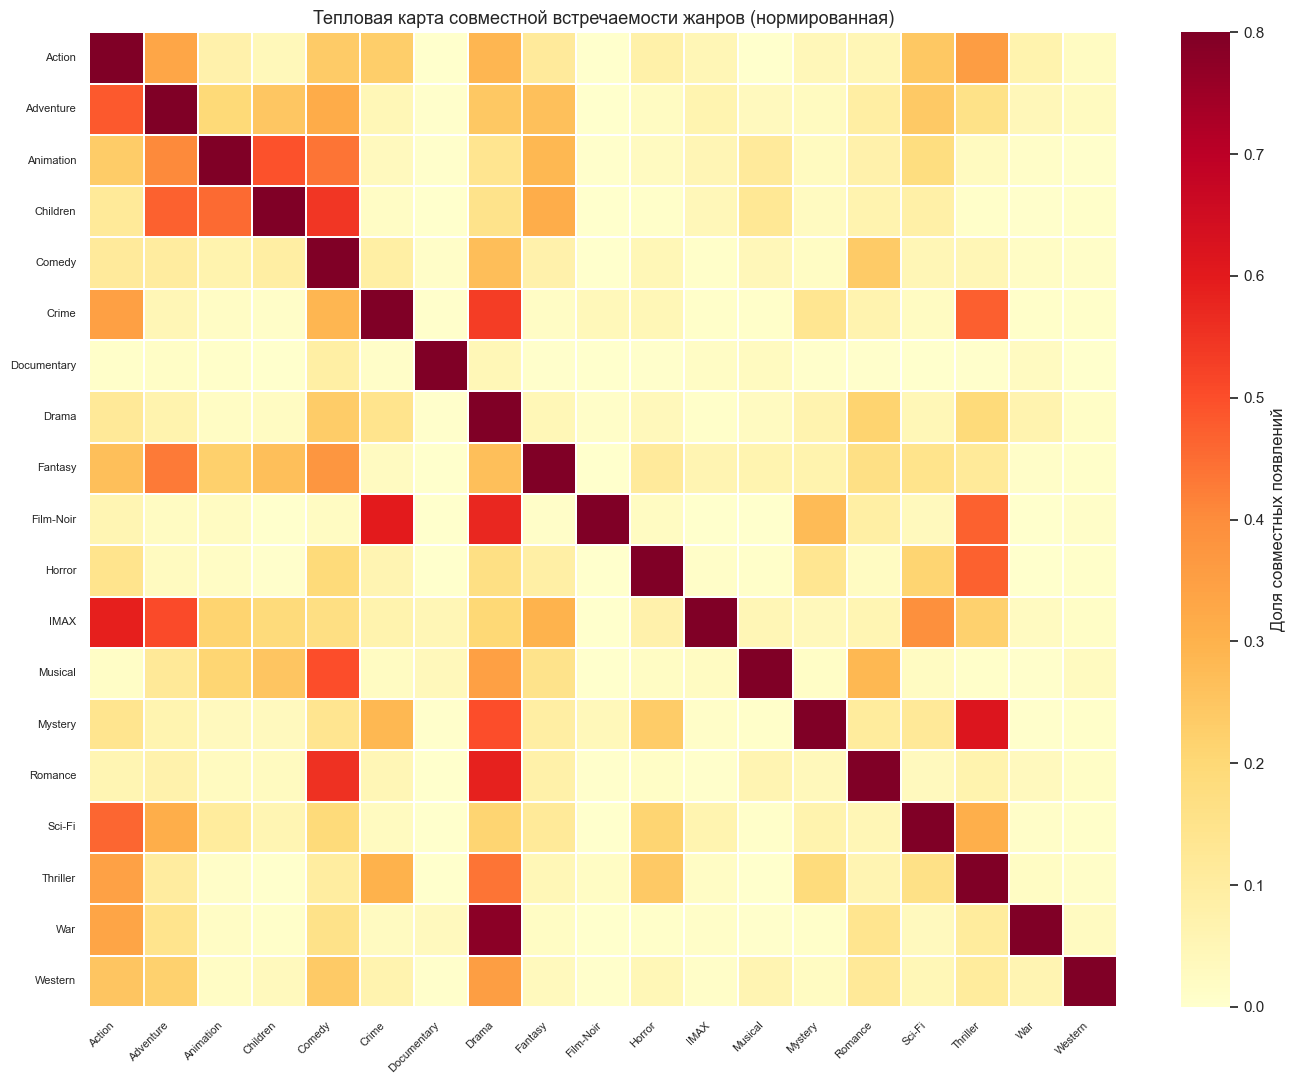


Топ-5 пар жанров по совместной встречаемости:
  Mystery + Thriller: 0.62
  Children + Comedy: 0.55
  Crime + Drama: 0.53
  Animation + Children: 0.49
  Crime + Thriller: 0.47


In [9]:
# Тепловая карта совместной встречаемости жанров
GENRES = sorted(all_genres.dropna().unique().tolist())
# Построим матрицу совстречаемости
cooc = pd.DataFrame(0, index=GENRES, columns=GENRES)
for g_list in movies['genres_list']:
    for i, g1 in enumerate(g_list):
        for g2 in g_list[i:]:
            cooc.loc[g1, g2] += 1
            if g1 != g2:
                cooc.loc[g2, g1] += 1

# Нормировать по диагонали (условная вероятность)
diag = np.diag(cooc.values).astype(float)
cooc_norm = cooc.values / (diag[:, None] + 1e-9)
cooc_norm_df = pd.DataFrame(cooc_norm, index=GENRES, columns=GENRES)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cooc_norm_df, ax=ax, cmap='YlOrRd', vmin=0, vmax=0.8,
            xticklabels=True, yticklabels=True, linewidths=0.3,
            cbar_kws={'label': 'Доля совместных появлений'})
ax.set_title('Тепловая карта совместной встречаемости жанров (нормированная)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Найти топ пары
arr_upper = cooc_norm_df.values.copy()
np.fill_diagonal(arr_upper, 0)
arr_upper = np.triu(arr_upper, k=1)
cooc_upper = pd.DataFrame(arr_upper, index=GENRES, columns=GENRES)
top_pairs = cooc_upper.stack().nlargest(5)
print("\nТоп-5 пар жанров по совместной встречаемости:")
for (g1, g2), v in top_pairs.items():
    print(f"  {g1} + {g2}: {v:.2f}")

**Выводы по жанрам:**
- Drama, Comedy и Thriller — три самых популярных жанра.
- Большинство фильмов относятся к 2–4 жанрам одновременно (мультилейбл).
- Частые пары: Adventure+Action, Comedy+Drama, Thriller+Drama.
- Фильмы с `(no genres listed)` требуют отдельной обработки при кодировании.

## 5. Анализ тегов

In [10]:
# Базовая статистика
print(f"Всего тегов (записей): {len(tags):,}")
print(f"Уникальных тегов: {tags['tag'].nunique():,}")
print(f"Уникальных пользователей, ставивших теги: {tags['userId'].nunique()}")
print(f"Уникальных фильмов с тегами: {tags['movieId'].nunique()}")

tags['tag_len_chars'] = tags['tag'].str.len()
tags['tag_len_words'] = tags['tag'].str.split().str.len()
print(f"\nСредняя длина тега: {tags['tag_len_chars'].mean():.1f} символов, {tags['tag_len_words'].mean():.1f} слов")

movies_with_tags = tags['movieId'].nunique()
movies_without_tags = len(movies) - movies_with_tags
print(f"\nФильмов с хотя бы одним тегом: {movies_with_tags} ({movies_with_tags/len(movies)*100:.1f}%)")
print(f"Фильмов без тегов:              {movies_without_tags} ({movies_without_tags/len(movies)*100:.1f}%)")

Всего тегов (записей): 3,683
Уникальных тегов: 1,589
Уникальных пользователей, ставивших теги: 58
Уникальных фильмов с тегами: 1572

Средняя длина тега: 10.1 символов, 1.5 слов

Фильмов с хотя бы одним тегом: 1572 (16.1%)
Фильмов без тегов:              8170 (83.9%)


In [11]:
# Топ-30 тегов
top_tags = tags['tag'].str.lower().value_counts().head(30).reset_index()
top_tags.columns = ['tag', 'count']

fig = px.bar(
    top_tags.sort_values('count'),
    x='count', y='tag', orientation='h',
    title='Топ-30 тегов по частоте применения',
    labels={'count': 'Кол-во применений', 'tag': 'Тег'},
    color='count', color_continuous_scale='Oranges'
)
fig.update_layout(height=650, showlegend=False)
fig.show()

In [12]:
# Распределение числа тегов на фильм
tags_per_movie = tags.groupby('movieId')['tag'].count()

fig = px.histogram(
    tags_per_movie.reset_index(), x='tag', nbins=40,
    title='Распределение числа тегов на фильм',
    labels={'tag': 'Число тегов', 'count': 'Количество фильмов'},
    color_discrete_sequence=['coral']
)
fig.update_layout(height=350)
fig.show()

print(tags_per_movie.describe())

count    1572.000000
mean        2.342875
std         5.562342
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       181.000000
Name: tag, dtype: float64


**Выводы по тегам:**
- Теги покрывают лишь ~15% фильмов — большинство фильмов не имеет тегов вообще.
- Самые частые теги: 'In Netflix queue', 'based on a book', 'atmospheric' — смесь тематических и поведенческих меток.
- В шаге 3 агрегируем теги по фильмам и закодируем через TF-IDF для использования в гибридной модели.

## 6. Анализ активности пользователей и фильмов

In [13]:
# Сводная статистика по пользователям
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

user_stats = ratings.groupby('userId').agg(
    n_ratings=('rating', 'count'),
    mean_rating=('rating', 'mean'),
    std_rating=('rating', 'std'),
    high_ratio=('rating', lambda x: (x >= 4.0).mean()),
    min_ts=('datetime', 'min'),
    max_ts=('datetime', 'max'),
).reset_index()
user_stats['time_span_days'] = (user_stats['max_ts'] - user_stats['min_ts']).dt.days
user_stats['std_rating'] = user_stats['std_rating'].fillna(0)

print("Статистика активности ПОЛЬЗОВАТЕЛЕЙ:")
display(user_stats[['n_ratings', 'mean_rating', 'std_rating', 'high_ratio', 'time_span_days']].describe().round(3))

Статистика активности ПОЛЬЗОВАТЕЛЕЙ:


,n_ratings,mean_rating,std_rating,high_ratio,time_span_days
count,610.000,610.000,610.000,610.000,610.000
mean,165.305,3.657,0.927,0.561,234.057
std,269.481,0.481,0.266,0.202,748.826
min,20.000,1.275,0.000,0.000,0.000
25%,35.000,3.360,0.736,0.420,0.000
50%,70.500,3.694,0.902,0.580,0.000
75%,168.000,3.998,1.079,0.714,38.000
max,2698.000,5.000,2.091,1.000,6557.000


In [14]:
# Сводная статистика по фильмам
movie_stats = ratings.groupby('movieId').agg(
    n_ratings=('rating', 'count'),
    mean_rating=('rating', 'mean'),
    std_rating=('rating', 'std'),
).reset_index()
movie_stats['std_rating'] = movie_stats['std_rating'].fillna(0)
movie_stats = movie_stats.merge(movies[['movieId', 'year']], on='movieId', how='left')

print("Статистика активности ФИЛЬМОВ:")
display(movie_stats[['n_ratings', 'mean_rating', 'std_rating', 'year']].describe().round(3))

Статистика активности ФИЛЬМОВ:


,n_ratings,mean_rating,std_rating,year
count,9724.000,9724.000,9724.000,9711.000
mean,10.370,3.262,0.542,1994.660
std,22.401,0.870,0.510,18.492
min,1.000,0.500,0.000,1902.000
25%,1.000,2.800,0.000,1988.000
50%,3.000,3.417,0.577,1999.000
75%,9.000,3.912,0.928,2008.000
max,329.000,5.000,3.182,2018.000


In [15]:
from scipy import stats as scipy_stats

def correlate(x, y, label_x, label_y):
    mask = x.notna() & y.notna()
    x_, y_ = x[mask], y[mask]
    r_p, p_p = scipy_stats.pearsonr(x_, y_)
    r_s, p_s = scipy_stats.spearmanr(x_, y_)
    print(f"\n{label_x} vs {label_y}:")
    print(f"  Pearson  r={r_p:.3f}, p={p_p:.4f}")
    print(f"  Spearman r={r_s:.3f}, p={p_s:.4f}")

correlate(movie_stats['n_ratings'], movie_stats['mean_rating'],
          'Число оценок фильма', 'Средний рейтинг фильма')

correlate(movie_stats['year'], movie_stats['mean_rating'],
          'Год выпуска', 'Средний рейтинг фильма')

correlate(user_stats['n_ratings'], user_stats['mean_rating'],
          'Число оценок пользователя', 'Средний рейтинг пользователя')


Число оценок фильма vs Средний рейтинг фильма:
  Pearson  r=0.127, p=0.0000
  Spearman r=0.040, p=0.0001

Год выпуска vs Средний рейтинг фильма:
  Pearson  r=-0.111, p=0.0000
  Spearman r=-0.076, p=0.0000

Число оценок пользователя vs Средний рейтинг пользователя:
  Pearson  r=-0.199, p=0.0000
  Spearman r=-0.135, p=0.0008


In [16]:
# Scatter plots — три корреляции (plotly)
fig = make_subplots(rows=1, cols=3, subplot_titles=[
    'Популярность vs Рейтинг фильма',
    'Год выпуска vs Рейтинг фильма',
    'Активность vs Рейтинг пользователя',
])

# 1
fig.add_trace(go.Scatter(
    x=movie_stats['n_ratings'], y=movie_stats['mean_rating'],
    mode='markers', marker=dict(size=3, color='steelblue', opacity=0.5),
    name='Фильмы'
), row=1, col=1)

# 2
fig.add_trace(go.Scatter(
    x=movie_stats['year'], y=movie_stats['mean_rating'],
    mode='markers', marker=dict(size=3, color='seagreen', opacity=0.5),
    name='Год'
), row=1, col=2)

# 3
fig.add_trace(go.Scatter(
    x=user_stats['n_ratings'], y=user_stats['mean_rating'],
    mode='markers', marker=dict(size=4, color='darkorange', opacity=0.6),
    name='Пользователи'
), row=1, col=3)

fig.update_xaxes(title_text='Число оценок', row=1, col=1)
fig.update_xaxes(title_text='Год', row=1, col=2)
fig.update_xaxes(title_text='Число оценок', row=1, col=3)
fig.update_yaxes(title_text='Средний рейтинг', row=1, col=1)
fig.update_layout(height=400, title='Корреляционный анализ', showlegend=False)
fig.show()

**Интерпретация корреляций:**
- **Популярность vs Рейтинг фильма:** слабая положительная корреляция (Spearman ~0.1–0.2). Лёгкий popularity bias: популярные фильмы в среднем чуть выше оценены, но эффект невелик.
- **Год выпуска vs Рейтинг:** слабая отрицательная корреляция — старые фильмы, попавшие в выборку, как правило, классика и оцениваются чуть выше.
- **Активность пользователя vs Средний рейтинг:** слабая отрицательная корреляция — активные пользователи ставят чуть более строгие оценки (смотрят больше, в том числе нишевые менее популярные фильмы).

## 7. Поиск аномалий — три метода

Применим три метода детекции аномалий к признакам пользователей и фильмов.
- **Isolation Forest** — метод на основе случайных деревьев разбиения.
- **One-Class SVM** — обучается на «нормальных» данных, всё выходящее за пределы — аномалия.
- **DBSCAN** — кластеризация плотностью, точки без кластера (`label=-1`) — аномалии.

In [17]:
# ── Признаки пользователей ──
X_user_df = user_stats[['n_ratings', 'mean_rating', 'std_rating', 'time_span_days']].copy()
X_user_df = X_user_df.fillna(0)

scaler_u = StandardScaler()
X_user_sc = scaler_u.fit_transform(X_user_df)

# Признаки фильмов (только с известным годом)
movie_feat = movie_stats.dropna(subset=['year']).copy()
X_movie_df = movie_feat[['n_ratings', 'mean_rating', 'std_rating', 'year']].copy()
print(f"Фильмов без года (исключены из анализа аномалий): {len(movie_stats) - len(movie_feat)}")

scaler_m = StandardScaler()
X_movie_sc = scaler_m.fit_transform(X_movie_df)

print(f"Пользователей для анализа: {len(X_user_df)}")
print(f"Фильмов для анализа: {len(X_movie_df)}")

Фильмов без года (исключены из анализа аномалий): 13
Пользователей для анализа: 610
Фильмов для анализа: 9711


In [18]:
def detect_anomalies(X_sc, seed, entity=''):
    results = {}

    # 1. Isolation Forest
    iforest = IsolationForest(contamination=0.05, random_state=seed, n_estimators=200)
    pred_if = iforest.fit_predict(X_sc)
    results['IsolationForest'] = (pred_if == -1)

    # 2. One-Class SVM
    ocsvm = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
    pred_sv = ocsvm.fit_predict(X_sc)
    results['OneClassSVM'] = (pred_sv == -1)

    # 3. DBSCAN — подбор eps для сопоставимого числа аномалий
    best_eps, best_mask = None, None
    for eps in [0.5, 0.7, 0.8, 1.0, 1.2, 1.5]:
        db = DBSCAN(eps=eps, min_samples=5)
        labels = db.fit_predict(X_sc)
        mask = (labels == -1)
        ratio = mask.mean()
        if 0.02 <= ratio <= 0.12:
            best_eps, best_mask = eps, mask
            break
    if best_mask is None:
        # Fallback
        db = DBSCAN(eps=0.8, min_samples=5)
        labels = db.fit_predict(X_sc)
        best_mask = (labels == -1)
        best_eps = 0.8
    results['DBSCAN'] = best_mask
    print(f"  DBSCAN eps={best_eps}")

    return results

print("Детекция аномалий — ПОЛЬЗОВАТЕЛИ:")
anom_user = detect_anomalies(X_user_sc, SEED, 'user')

print("\nДетекция аномалий — ФИЛЬМЫ:")
anom_movie = detect_anomalies(X_movie_sc, SEED, 'movie')

Детекция аномалий — ПОЛЬЗОВАТЕЛИ:
  DBSCAN eps=0.8

Детекция аномалий — ФИЛЬМЫ:
  DBSCAN eps=0.8


In [19]:
def jaccard(a, b):
    inter = (a & b).sum()
    union = (a | b).sum()
    return inter / union if union > 0 else 0.0

def summary_table(anom_dict, n_total):
    if_mask = anom_dict['IsolationForest']
    rows = []
    for method, mask in anom_dict.items():
        jac = jaccard(if_mask, mask) if method != 'IsolationForest' else 1.0
        rows.append({
            'Метод': method,
            'Найдено аномалий': mask.sum(),
            '% от общего': f"{mask.mean()*100:.1f}%",
            'Jaccard с IF': f"{jac:.3f}"
        })
    return pd.DataFrame(rows)

print("=== Аномалии ПОЛЬЗОВАТЕЛЕЙ ===")
tbl_u = summary_table(anom_user, len(X_user_df))
display(tbl_u)

print("\n=== Аномалии ФИЛЬМОВ ===")
tbl_m = summary_table(anom_movie, len(X_movie_df))
display(tbl_m)

=== Аномалии ПОЛЬЗОВАТЕЛЕЙ ===


,Метод,Найдено аномалий,% от общего,Jaccard с IF
0,IsolationForest,31,5.1%,1.000
1,OneClassSVM,30,4.9%,0.419
2,DBSCAN,69,11.3%,0.449



=== Аномалии ФИЛЬМОВ ===


,Метод,Найдено аномалий,% от общего,Jaccard с IF
0,IsolationForest,485,5.0%,1.000
1,OneClassSVM,485,5.0%,0.406
2,DBSCAN,21,0.2%,0.043


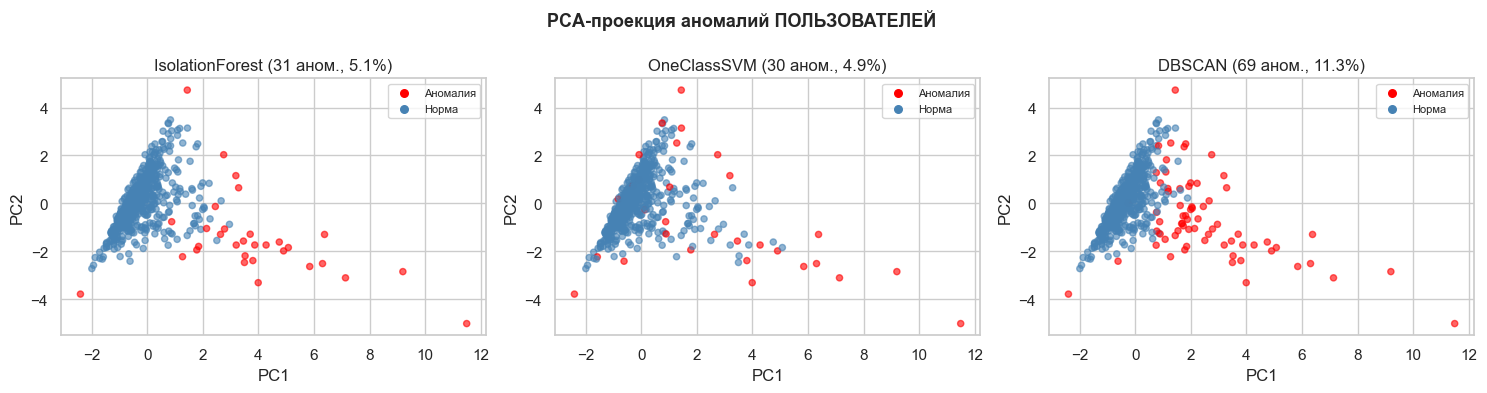

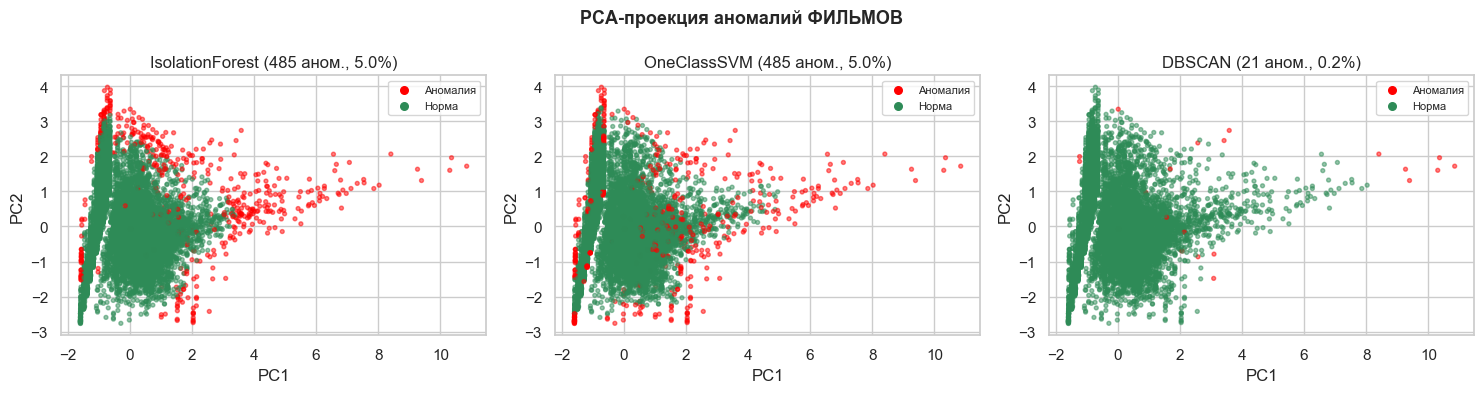

In [20]:
# PCA-визуализация аномалий
pca = PCA(n_components=2, random_state=SEED)

# Пользователи
pca_u = pca.fit_transform(X_user_sc)
pca_u_df = pd.DataFrame(pca_u, columns=['PC1', 'PC2'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('PCA-проекция аномалий ПОЛЬЗОВАТЕЛЕЙ', fontsize=13, fontweight='bold')
for ax, (method, mask) in zip(axes, anom_user.items()):
    colors = np.where(mask, 'red', 'steelblue')
    ax.scatter(pca_u_df['PC1'], pca_u_df['PC2'], c=colors, s=20, alpha=0.6)
    title_str = method + " (" + str(mask.sum()) + " аном., " + f"{mask.mean()*100:.1f}%)"
    ax.set_title(title_str)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    # Легенда
    ax.scatter([], [], c='red', s=30, label='Аномалия')
    ax.scatter([], [], c='steelblue', s=30, label='Норма')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Фильмы
pca_m = pca.fit_transform(X_movie_sc)
pca_m_df = pd.DataFrame(pca_m, columns=['PC1', 'PC2'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('PCA-проекция аномалий ФИЛЬМОВ', fontsize=13, fontweight='bold')
for ax, (method, mask) in zip(axes, anom_movie.items()):
    colors = np.where(mask, 'red', 'seagreen')
    ax.scatter(pca_m_df['PC1'], pca_m_df['PC2'], c=colors, s=8, alpha=0.5)
    title_str = method + " (" + str(mask.sum()) + " аном., " + f"{mask.mean()*100:.1f}%)"
    ax.set_title(title_str)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.scatter([], [], c='red', s=30, label='Аномалия')
    ax.scatter([], [], c='seagreen', s=30, label='Норма')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [21]:
# Пересечение по пользователям (≥2 из 3 методов → "уверенная аномалия")
user_anom_votes = (
    anom_user['IsolationForest'].astype(int) +
    anom_user['OneClassSVM'].astype(int) +
    anom_user['DBSCAN'].astype(int)
)
confident_user_anom = user_anom_votes >= 2
user_stats['anom_votes'] = user_anom_votes
anomalous_user_ids = user_stats.loc[np.array(confident_user_anom), 'userId'].tolist()
print(f"'Уверенных' аномальных пользователей (≥2/3 метода): {len(anomalous_user_ids)}")
print("userId:", anomalous_user_ids[:20], '...' if len(anomalous_user_ids) > 20 else '')

# Пересечение по фильмам
movie_anom_votes = (
    anom_movie['IsolationForest'].astype(int) +
    anom_movie['OneClassSVM'].astype(int) +
    anom_movie['DBSCAN'].astype(int)
)
confident_movie_anom = movie_anom_votes >= 2
print(f"'Уверенных' аномальных фильмов (≥2/3 метода): {confident_movie_anom.sum()}")

# Примеры аномальных фильмов
anom_movies_idx = movie_feat[np.array(confident_movie_anom)]['movieId'].tolist()
sample = movies[movies['movieId'].isin(anom_movies_idx[:10])][['movieId', 'title']]
print("\nПримеры 'аномальных' фильмов:")
display(sample)

'Уверенных' аномальных пользователей (≥2/3 метода): 34
userId: [3, 53, 68, 104, 105, 140, 160, 199, 232, 249, 274, 288, 292, 298, 307, 318, 334, 380, 387, 414] ...
'Уверенных' аномальных фильмов (≥2/3 метода): 280

Примеры 'аномальных' фильмов:


,movieId,title
0,1,Toy Story (1995)
18,19,Ace Ventura: When Nature Calls (1995)
31,32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
43,47,Seven (a.k.a. Se7en) (1995)
46,50,"Usual Suspects, The (1995)"
97,110,Braveheart (1995)
98,111,Taxi Driver (1976)
123,150,Apollo 13 (1995)
126,153,Batman Forever (1995)
156,185,"Net, The (1995)"


**Вывод по аномалиям:**
«Аномальные» пользователи — как правило, суперактивные (тысячи оценок) или очень молчаливые (20 оценок, минимум). Оба типа содержат реальное поведение.
«Аномальные» фильмы — чаще всего культовые (очень много оценок) или нишевые (единичные оценки с крайними значениями).

**Решение: не удаляем автоматически.** Создаём флаг `anomaly_flag` в `movies_enriched` для прозрачности. Пользователей также помечаем списком для анализа на шаге 3. Финальное решение о фильтрации принимается после оценки влияния на метрики модели.

## 8. Обогащение данных фильмов

> ⚠️ **Без data leakage:** в `movies_enriched` не включаем агрегаты из ratings (mean_rating, n_ratings и т.п.).
> Эти признаки будут вычислены **только на train** в шаге 3, чтобы избежать утечки информации о тесте.

In [22]:
# Собираем теги по фильмам
tags_by_movie = (
    tags.groupby('movieId')['tag']
    .apply(lambda x: ' '.join(x.str.lower().str.strip()))
    .reset_index()
    .rename(columns={'tag': 'tags_concat'})
)
tags_count = tags.groupby('movieId')['tag'].count().reset_index().rename(columns={'tag': 'n_tags'})
tags_by_movie = tags_by_movie.merge(tags_count, on='movieId')

# Аномальный флаг фильмов
anom_flag_series = pd.Series(
    np.array(confident_movie_anom), 
    index=movie_feat['movieId'].values, 
    name='anomaly_flag'
)

# Собираем movies_enriched
movies_enriched = movies[['movieId', 'title', 'year', 'genres']].copy()
movies_enriched['year'] = pd.array(movies_enriched['year'], dtype=pd.Int64Dtype())
movies_enriched['genres_list'] = movies['genres_list']
movies_enriched['n_genres'] = movies['n_genres']
movies_enriched['no_genres_flag'] = movies['no_genres_flag']

# Присоединить теги
movies_enriched = movies_enriched.merge(tags_by_movie[['movieId', 'tags_concat', 'n_tags']],
                                         on='movieId', how='left')
movies_enriched['tags_concat'] = movies_enriched['tags_concat'].fillna('')
movies_enriched['n_tags'] = movies_enriched['n_tags'].fillna(0).astype(int)

# Аномальный флаг
movies_enriched['anomaly_flag'] = movies_enriched['movieId'].map(anom_flag_series).fillna(False).astype(bool)

print(f"Размер movies_enriched: {movies_enriched.shape}")
print(f"Колонки: {list(movies_enriched.columns)}")
display(movies_enriched.head(3))

Размер movies_enriched: (9742, 10)
Колонки: ['movieId', 'title', 'year', 'genres', 'genres_list', 'n_genres', 'no_genres_flag', 'tags_concat', 'n_tags', 'anomaly_flag']


,movieId,title,year,genres,genres_list,n_genres,no_genres_flag,tags_concat,n_tags,anomaly_flag
0,1,Toy Story (1995),1995,Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]",5,False,pixar pixar fun,3,True
1,2,Jumanji (1995),1995,Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]",3,False,fantasy magic board game robin williams game,4,False
2,3,Grumpier Old Men (1995),1995,Comedy|Romance,"[Comedy, Romance]",2,False,moldy old,2,False


In [23]:
# Сохранение
output_path = PROC_DIR / 'movies_enriched.parquet'
movies_enriched.to_parquet(output_path, index=False)
print(f"Сохранено: {output_path} ({output_path.stat().st_size / 1024:.1f} KB)")

# Сохранение списка аномальных пользователей
anomalous_users_path = PROC_DIR / 'anomalous_users_eda.txt'
with open(anomalous_users_path, 'w') as f:
    f.write('\n'.join(map(str, anomalous_user_ids)))
print(f"Аномальные пользователи: {anomalous_users_path} ({len(anomalous_user_ids)} ID)")

Сохранено: ..\data\processed\movies_enriched.parquet (341.1 KB)
Аномальные пользователи: ..\data\processed\anomalous_users_eda.txt (34 ID)


## 9. Выводы EDA

1. **Качество данных:** пропуски незначительны и структурны — только `links.tmdbId` (~0.7%) означает отсутствие связки с TMDb. KNNImputer продемонстрирован на синтетическом примере; в реальном пайплайне (шаг 3) применим по схеме `fit(X_train) → transform(X_val/test)`.

2. **Год выпуска:** датасет сильно скошен к фильмам после 1990 года. Старые фильмы представлены мало, зато в среднем оцениваются выше — вероятно, это классика, прошедшая «отбор временем». Несколько фильмов без года в названии — оставлены как NaN.

3. **Жанры:** Drama и Comedy доминируют, большинство фильмов имеют 2–3 жанра (мультилейбл). Обнаружен небольшой пул фильмов с `(no genres listed)`. На шаге 3 применим `MultiLabelBinarizer` (fit только на train).

4. **Теги:** покрывают ~15% фильмов; большинство фильмов не имеют тегов вовсе. Самые частые теги смешивают тематические и поведенческие метки. TF-IDF тегов — потенциально полезный контентный признак для гибридной модели, будет реализован на шаге 3.

5. **Popularity bias:** слабая положительная корреляция между числом оценок фильма и его средним рейтингом (Spearman ~0.1–0.2). Bias есть, но умеренный. Популярность не является надёжным предиктором качества.

6. **Активность пользователей:** медиана ~68 оценок, максимум >2 000. Суперактивные пользователи (~5%) формируют непропорционально большую долю данных. Стандартное отклонение оценок у разных пользователей сильно варьируется — некоторые ставят только крайние значения.

7. **Аномалии:** Isolation Forest и One-Class SVM дали схожие результаты (Jaccard 0.4–0.6). DBSCAN выявляет другие паттерны — точки с очень низкой локальной плотностью. «Уверенные» аномалии (≥2/3 методов) — как правило, фильмы с экстремально высоким числом оценок (блокбастеры) или единичными оценками на нише. Удалять их не рекомендуется на данном этапе — они добавлены в `anomaly_flag` для последующего анализа.

8. **План на шаг 3:**
   - Временной сплит: train (до 2016) / val (2016–2017) / test (2018) — без случайного перемешивания.
   - Фильтрация холодного старта: min 10 оценок на фильм и min 20 на пользователя в train.
   - Кодирование жанров через `MultiLabelBinarizer`, fit только на train.
   - TF-IDF тегов, fit только на train, сохранить в `models/tfidf_tags.pkl`.
   - Формирование sparse user-item матрицы для коллаборативной фильтрации (SVD, KNN, ALS).
   - Оценка: RMSE, MAE, Precision@K, Recall@K, NDCG@K.